# Edward Moswane Assignment 12: Neural Network and Deep Learning Basics

# Dataset Preparation

In [ ]:
# Importing significant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix)

Data Loading and Visualization:

In [ ]:
# Show TensorFlow version
print("TensorFlow version:", tf.__version__)

# Loading the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

TensorFlow version: 2.20.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


Defining the CIFAR-10 classes

In [ ]:
# CIFAR-10 class names
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

print("Classes:")
for i, name in enumerate(class_names):
    print(i, "-", name)

Classes:
0 - airplane
1 - automobile
2 - bird
3 - cat
4 - deer
5 - dog
6 - frog
7 - horse
8 - ship
9 - truck


Explore the dataset EDA

In [ ]:
# Show summary of dataset information
print("Number of training images:", len(x_train))
print("Number of testing images:", len(x_test))
print("Image dimensions:", x_train.shape[1:])
print("Number of classes:", len(class_names))

# Checking pixel value range
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Number of training images: 50000
Number of testing images: 10000
Image dimensions: (32, 32, 3)
Number of classes: 10
Minimum pixel value: 0
Maximum pixel value: 255


Visualization of Sample Images

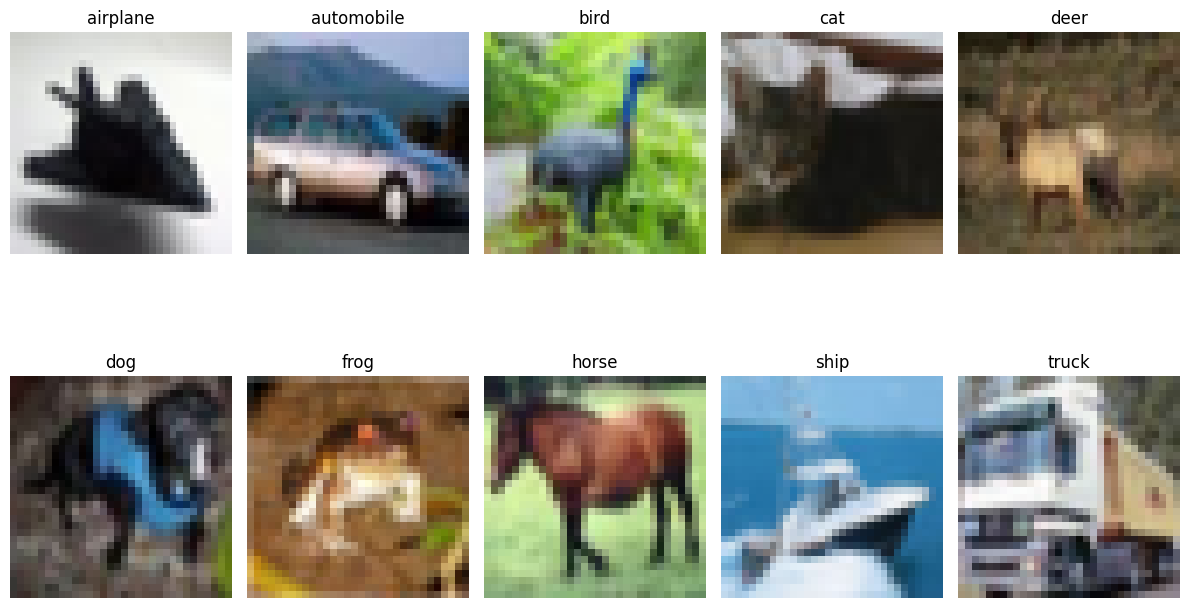

In [ ]:
# Visualizing single sample image from each CIFAR-10 class

plt.figure(figsize=(12, 8))

for class_id in range(10):

    # Finding the first image belonging to this class
    index = np.where(y_train.flatten() == class_id)[0][0]

    plt.subplot(2, 5, class_id + 1)
    plt.imshow(x_train[index])
    plt.title(class_names[class_id])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Image Preprocessing

In [ ]:
# Normalizing pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("New minimum pixel value:", x_train.min())
print("New maximum pixel value:", x_train.max())

New minimum pixel value: 0.0
New maximum pixel value: 1.0


Converting labels to categorical format

In [ ]:
# Convert class labels to one-hot encoded format
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print("Original label shape:", y_train.shape)
print("Categorical label shape:", y_train_cat.shape)

Original label shape: (50000, 1)
Categorical label shape: (50000, 10)


# Neural Network Implementation

Construct a simple feedforward neural network

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')])

# Show model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

Compilation: Compile the model

In [ ]:
# Compiling the neural network
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

print("Model compiled successfully.")

Model compiled successfully.


Training: Train the model

In [ ]:
# Training the neural network
history = model.fit(x_train,y_train_cat,epochs=10,batch_size=64,validation_split=0.2,verbose=1)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3091 - loss: 1.9371 - val_accuracy: 0.3479 - val_loss: 1.8215
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.3737 - loss: 1.7717 - val_accuracy: 0.3752 - val_loss: 1.7601
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3945 - loss: 1.7124 - val_accuracy: 0.3633 - val_loss: 1.7636
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4076 - loss: 1.6749 - val_accuracy: 0.3886 - val_loss: 1.7323
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4181 - loss: 1.6412 - val_accuracy: 0.4101 - val_loss: 1.6684
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4243 - loss: 1.6232 - val_accuracy: 0.4041 - val_loss: 1.6825
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4326 - loss: 1.6015 - val_accuracy: 0.4126 - val_loss: 1.6478
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4405 - loss: 1.5853 - val_accur

Plot training and validation accuracy

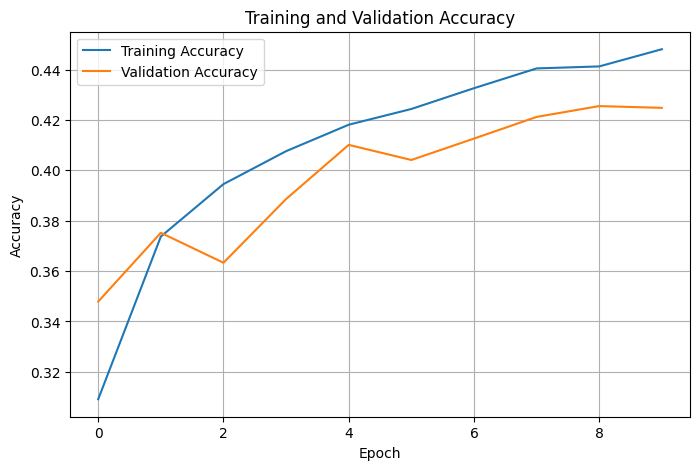

In [ ]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

Plot training and validation loss

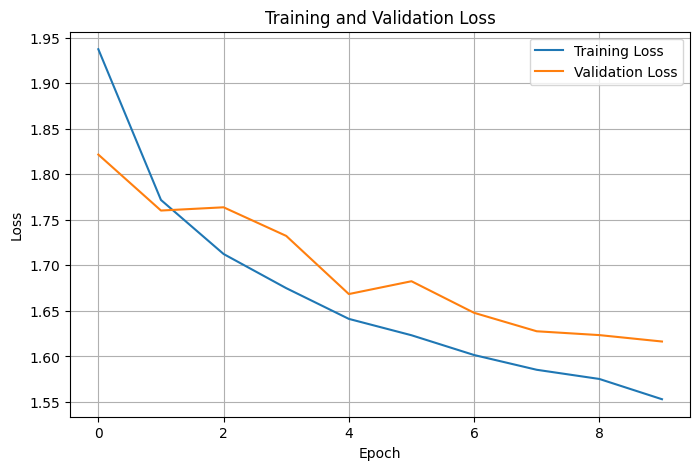

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

# Model Evaluation on the tested dataset

In [ ]:
# Evaluate the model on the test dataset

test_loss, test_accuracy = model.evaluate(x_test,y_test_cat,verbose=0)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print("Test Accuracy (%):", round(test_accuracy * 100, 2), "%")

Test Loss: 1.5939
Test Accuracy: 0.4298
Test Accuracy (%): 42.98 %


Generate predictions

In [ ]:
# Generate predictions for the test set

y_pred_prob = model.predict(x_test, verbose=0)

# Convert predicted probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert actual one-hot labels back to class labels
y_true = y_test.flatten()

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 10000


Accuracy, Precision, Recall and F1-score

In [ ]:
# Calculate classification metrics

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 0.4298
Precision: 0.4537
Recall   : 0.4298
F1-Score : 0.4271


Classification report to evaluate performance across all categories.

In [ ]:
# Show detailed classification report

print("___________________Classification Report:_____________________\n")
print(classification_report(y_true,y_pred,target_names=class_names))

___________________Classification Report:_____________________

              precision    recall  f1-score   support

    airplane       0.37      0.69      0.48      1000
  automobile       0.58      0.48      0.53      1000
        bird       0.31      0.34      0.32      1000
         cat       0.30      0.32      0.31      1000
        deer       0.45      0.23      0.31      1000
         dog       0.37      0.34      0.35      1000
        frog       0.41      0.59      0.48      1000
       horse       0.59      0.37      0.45      1000
        ship       0.62      0.51      0.56      1000
       truck       0.55      0.43      0.48      1000

    accuracy                           0.43     10000
   macro avg       0.45      0.43      0.43     10000
weighted avg       0.45      0.43      0.43     10000



Confusion matrix

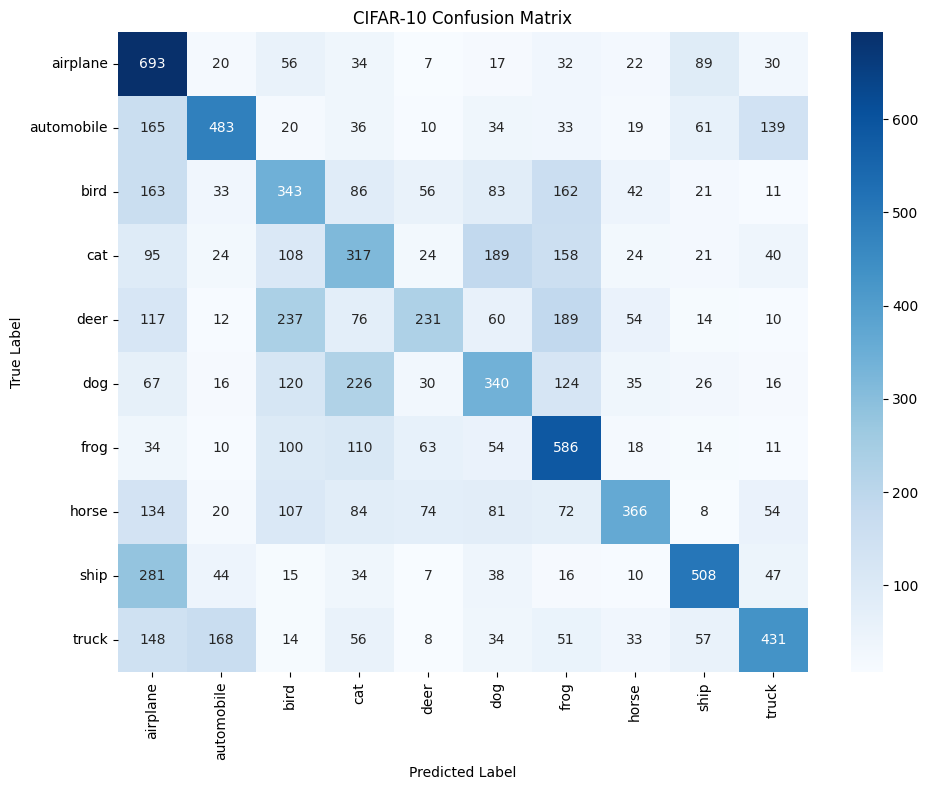

In [ ]:
# Creating confusion matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names)

plt.title('CIFAR-10 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

Model improvement

In [ ]:
# Improved feedforward neural network
model_2 = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')])

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the improved model
model_2.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# Training the improved model
history_2 = model_2.fit(x_train,y_train_cat,epochs=10,batch_size=64,validation_split=0.2,verbose=1)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.3168 - loss: 1.9015 - val_accuracy: 0.3655 - val_loss: 1.7884
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.3876 - loss: 1.6989 - val_accuracy: 0.4128 - val_loss: 1.6514
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.4215 - loss: 1.6215 - val_accuracy: 0.4146 - val_loss: 1.6441
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.4387 - loss: 1.5710 - val_accuracy: 0.4230 - val_loss: 1.6170
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.4551 - loss: 1.5300 - val_accuracy: 0.4443 - val_loss: 1.5641
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.4620 - loss: 1.5071 - val_accuracy: 0.4500 - val_loss: 1.5647
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.4727 - loss: 1.4778 - val_accuracy: 0.4441 - val_loss: 1.5738
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.4780 - loss: 1.4584 - 

Compare the two models

In [ ]:
# Evaluate improved model
test_loss_2, test_accuracy_2 = model_2.evaluate(x_test,y_test_cat,verbose=0)

print("Original Model Accuracy:", round(test_accuracy * 100, 2), "%")
print("Improved Model Accuracy:", round(test_accuracy_2 * 100, 2), "%")

Original Model Accuracy: 42.98 %
Improved Model Accuracy: 47.99 %


In [ ]:
# Comparing model performance
comparison = pd.DataFrame({'Model': ['Original Model', 'Improved Model'],'Test Accuracy': [test_accuracy,test_accuracy_2]})

comparison['Test Accuracy (%)'] = comparison['Test Accuracy'] * 100

comparison

,Model,Test Accuracy,Test Accuracy (%)
0,Original Model,0.4298,42.98
1,Improved Model,0.4799,47.99


Plot of improved model performance

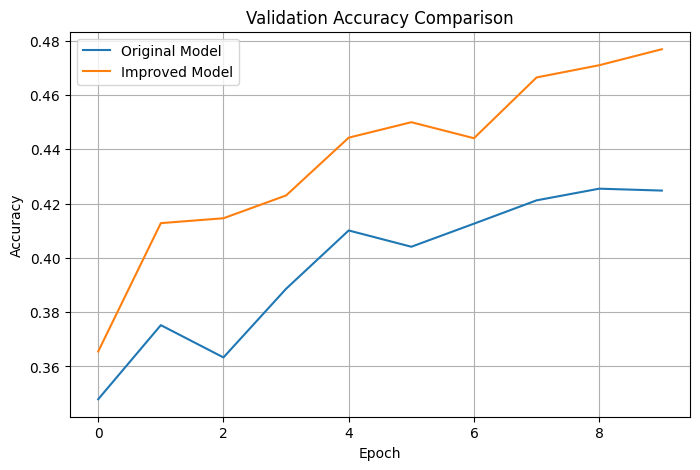

In [ ]:
# Compare training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history['val_accuracy'],label='Original Model')
plt.plot(history_2.history['val_accuracy'],label='Improved Model')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

**Summary and Conclusion of Findings**
The CIFAR-10 feedforward neural network achieved 42.98% test accuracy, with 45.37% precision, 42.98% recall, and 42.71% F1-score. The improved model added another hidden layer and more neurons to increase the test accuracy to 47.99%. The outcomes shows that increasing the model size improved its classification performance, although some visually similar classes were still difficult to distinguish. In conclusion, this assignment project demonstrated how a feedforward neural network can be used for image classification. There is more work that needs to be done in future to further improve accuracy.

Colab Link

https://colab.research.google.com/drive/1U73vpdYpQulFJJ7CKzrnLl8HiCXYVDx6?usp=sharing